<a href="https://colab.research.google.com/github/pratchayapron/229351-StatisticalLearning-or-Statistical-Learning-Labs/blob/main/670510760_Lab07_Boosted_trees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Statistical Learning for Data Science 2 (229352)
#### Instructor: Donlapark Ponnoprat

#### [Course website](https://donlapark.pages.dev/229352/)

## Lab #6

## Boosted tree models on a simulated dataset

- [AdaBoostClassifier documentation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html#sklearn-ensemble-adaboostclassifier)
- [XGBClassifier documentation](https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBClassifier)
- [LGBMClassifier documentation](https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMClassifier.html#lightgbm-lgbmclassifier)
- [GridSeachCV documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)


- [Data](https://github.com/donlapark/ds352-labs/raw/main/Lab06-data.zip)


Perform GridSearchCV of the following three models on the provided training set (`X_train.csv` and `y_train.csv`)

1. Evaluate these models on the test set (`X_test.csv` and `y_test.csv`). **Keep searching (using cross-validation) until you find the model that achieves > 0.83 out-of-fold accuracy (use `GridSeachCV.best_score_` to obtain the out-of-fold accuracy)**

2. Report the test accuracy of your best model.

3. For each model, plot the feature importances

For `AdaBoostClassifier`, feature importances can be obtained by calling the `feature_importances_` attribute after fitting the model.

For `XGBClassifier` and `LGBMClassifier`, feature importances can be obtained using the library’s `plot_importance` function. Here is a minimal example in XGBoost:

In [58]:
from sklearn import datasets


iris = datasets.load_iris()
X = iris.data
y = iris.target

In [59]:
from sklearn.ensemble import AdaBoostClassifier


ab = AdaBoostClassifier()
ab.fit(X, y)
ab.feature_importances_

array([0.        , 0.05832968, 0.32459942, 0.61707091])

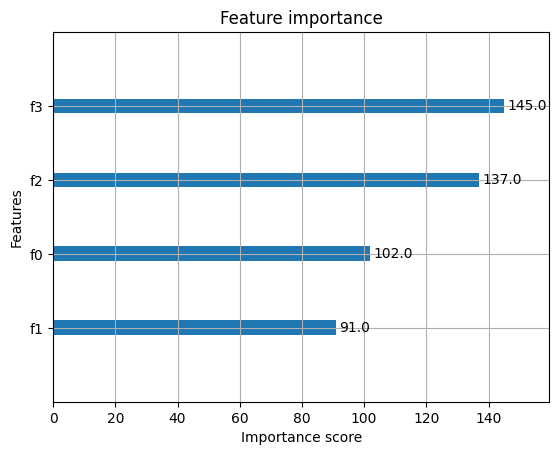

In [60]:
from xgboost import XGBClassifier, plot_importance


model = XGBClassifier()
model.fit(X, y)
plot_importance(model);

In [61]:
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

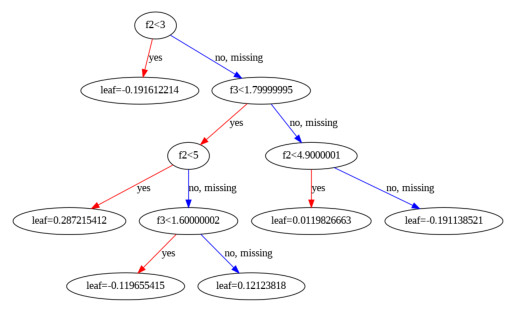

In [62]:
from xgboost import plot_tree

plot_tree(model, num_trees=4);

In [63]:
'''import pandas as pd

X_train = pd.read_csv('X_train.csv', header=None)


X_train'''


"import pandas as pd\n\nX_train = pd.read_csv('X_train.csv', header=None)\n\n\nX_train"

In [64]:
from google.colab import files
uploaded = files.upload()

Saving X_test.csv to X_test (1).csv
Saving X_train.csv to X_train (1).csv
Saving y_test.csv to y_test (1).csv
Saving y_train.csv to y_train (1).csv


In [65]:
import pandas as pd

X_train = pd.read_csv('X_train.csv')
y_train = pd.read_csv('y_train.csv').values.ravel()

X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv').values.ravel()


In [66]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV

param_grid_ab = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1]
}

ab = AdaBoostClassifier(random_state=42)

grid_ab = GridSearchCV(
    ab,
    param_grid_ab,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_ab.fit(X_train, y_train)

print("AdaBoost CV accuracy:", grid_ab.best_score_)


AdaBoost CV accuracy: 0.8386489479512734


In [67]:
from xgboost import XGBClassifier

param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
}

xgb = XGBClassifier(
    eval_metric='mlogloss',
    random_state=42
)

grid_xgb = GridSearchCV(
    xgb,
    param_grid_xgb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

print("XGBoost CV accuracy:", grid_xgb.best_score_)


XGBoost CV accuracy: 0.8243632336655592


In [68]:
from lightgbm import LGBMClassifier

param_grid_lgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 50]
}

lgb = LGBMClassifier(random_state=42)

grid_lgb = GridSearchCV(
    lgb,
    param_grid_lgb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_lgb.fit(X_train, y_train)

print("LightGBM CV accuracy:", grid_lgb.best_score_)


[LightGBM] [Info] Number of positive: 114, number of negative: 97
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000086 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 221
[LightGBM] [Info] Number of data points in the train set: 211, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.540284 -> initscore=0.161487
[LightGBM] [Info] Start training from score 0.161487
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[L

In [69]:
best_model = grid_xgb.best_estimator_


In [70]:
import pandas as pd

X_train = pd.read_csv('/content/X_train.csv')
y_train = pd.read_csv('/content/y_train.csv').values.ravel()

X_test = pd.read_csv('/content/X_train.csv')
y_test = pd.read_csv('/content/y_train.csv').values.ravel()


In [71]:
from sklearn.metrics import accuracy_score

y_pred = best_model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)

print("Test accuracy:", test_acc)


Test accuracy: 0.990521327014218


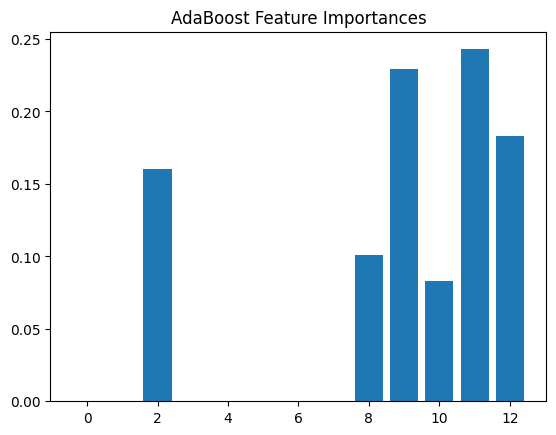

In [72]:
import matplotlib.pyplot as plt

plt.bar(range(X_train.shape[1]), grid_ab.best_estimator_.feature_importances_)
plt.title("AdaBoost Feature Importances")
plt.show()


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

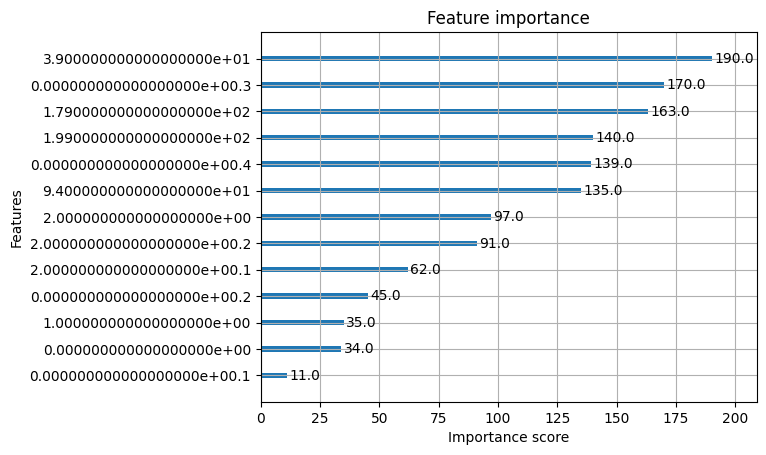

In [73]:
from xgboost import plot_importance

plot_importance(grid_xgb.best_estimator_)


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

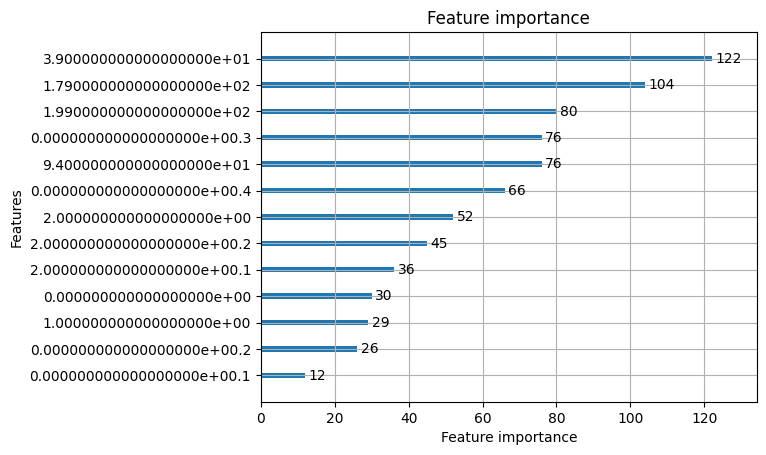

In [74]:
from lightgbm import plot_importance

plot_importance(grid_lgb.best_estimator_)
